# Representation Analysis

Implements the full RepE methodology for multi-turn jailbreak conversations.

## Positions (Zhao et al.)
```
... [user content] <|eot_id|> <|start_header_id|> assistant <|end_header_id|> \n\n
         ↑               ↑
      t_inst        t_post_inst
```
- `h_inst` (t_inst): encodes *harmfulness* — last user token before EOT  
- `h_post` (t_post_inst): encodes *refusal* — the EOT token itself

## Behavioral categories
| Label | Condition |
|---|---|
| `accepted_harmful` | harmful + `attack_success=True` |
| `refused_harmful` | harmful + `attack_success=False` |
| `accepted_harmless` | benign + `attack_success=True` (verdict=jailbroken) |
| `refused_harmless` | benign + `attack_success=False` |

## Centroid options
| Option | Description |
|---|---|
| **A** | Final accepted turn only |
| **B** | Mean across all accepted turns (trajectory average) |
| **C** | Per-position: early (k=1), mid (k≈n/2), late (k=n) |

## Train / test split
- Train: `attempt ≤ 16` (reps 1–16)
- Test:  `attempt > 16` (reps 17–20)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT = repo_root / "data" / "representations"
FRAMEWORKS = ["crescendo", "actorattack", "xteaming"]
SPLITS      = ["harmful", "benign"]
N_LAYERS    = 32
HIDDEN_DIM  = 4096

TRAIN_MAX_ATTEMPT = 16   # attempts 1–16 → train
# test: attempts 17–20

CATEGORY_COLORS = {
    "accepted_harmful":  "#d62728",
    "refused_harmful":   "#ff9896",
    "accepted_harmless": "#1f77b4",
    "refused_harmless":  "#aec7e8",
}

print(f"Repo root: {repo_root}")
print(f"REPR_ROOT: {REPR_ROOT}")

Repo root: /Users/lisahusieva/Desktop/multi-turn-rep-eng
REPR_ROOT: /Users/lisahusieva/Desktop/multi-turn-rep-eng/data/representations


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load all trajectory data ──────────────────────────────────────────────────
# Each dataset: flat rows matching npy array positions.
# Keys in traj dict: (framework, split) → {"meta": DataFrame, "h_inst": (N, 32, 4096), "h_post": (N, 32, 4096)}

traj = {}

for fw in FRAMEWORKS:
    for split in SPLITS:
        folder = REPR_ROOT / "trajectories" / f"{fw}_{split}"
        meta   = pd.read_parquet(folder / "metadata.parquet")
        h_inst = np.load(folder / "h_inst.npy")       # float16, (N, 32, 4096)
        h_post = np.load(folder / "h_post_inst.npy")  # float16, (N, 32, 4096)
        assert len(meta) == len(h_inst) == len(h_post)
        traj[(fw, split)] = {"meta": meta, "h_inst": h_inst, "h_post": h_post}
        print(f"{fw:15s} {split:8s}  rows={len(meta):6d}  "
              f"convs={meta['conversation_id'].nunique():5d}")

# ── Single-turn baseline ──────────────────────────────────────────────────────
st = {}
for split in SPLITS:
    folder = REPR_ROOT / "single_turn" / split
    meta   = pd.read_parquet(folder / "metadata.parquet")
    h_inst = np.load(folder / "h_inst.npy")       # (100, 32, 4096)
    h_post = np.load(folder / "h_post_inst.npy")
    st[split] = {"meta": meta, "h_inst": h_inst, "h_post": h_post}
    print(f"single_turn   {split:8s}  rows={len(meta):6d}")

print("\nDone loading.")

crescendo       harmful   rows= 11985  convs= 1994
crescendo       benign    rows=  8323  convs= 1991
actorattack     harmful   rows= 11982  convs= 1997
actorattack     benign    rows= 11988  convs= 1998
xteaming        harmful   rows=  6461  convs= 1945
xteaming        benign    rows=  7003  convs= 1999
single_turn   harmful   rows=   100
single_turn   benign    rows=   100

Done loading.


In [3]:
# ── Assign behavioral categories & train/test split ──────────────────────────
# Adds 'category' and 'split' columns to each metadata DataFrame (in-place).

def assign_category(row):
    """Map goal_type × attack_success → behavioral category."""
    if row["goal_type"] == "harmful":
        return "accepted_harmful" if row["attack_success"] else "refused_harmful"
    else:  # benign — attack_success is True iff verdict==jailbroken
        return "accepted_harmless" if row["attack_success"] else "refused_harmless"


for key, d in traj.items():
    m = d["meta"]
    m["category"] = m.apply(assign_category, axis=1)
    m["data_split"] = np.where(m["attempt"] <= TRAIN_MAX_ATTEMPT, "train", "test")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Framework':<14} {'Split':<8} {'Train convs':>12} {'Test convs':>11}  Category breakdown")
print("-" * 80)
for fw in FRAMEWORKS:
    for split in SPLITS:
        m = traj[(fw, split)]["meta"]
        # Per-conversation stats (one row per conversation = last-turn row)
        convs = m.groupby("conversation_id").last().reset_index()
        train_n = (convs["data_split"] == "train").sum()
        test_n  = (convs["data_split"] == "test").sum()
        cats    = convs["category"].value_counts().to_dict()
        print(f"{fw:<14} {split:<8} {train_n:>12} {test_n:>11}  {cats}")

Framework      Split     Train convs  Test convs  Category breakdown
--------------------------------------------------------------------------------
crescendo      harmful          1597         397  {'accepted_harmful': 1621, 'refused_harmful': 373}
crescendo      benign           1594         397  {'accepted_harmless': 1873, 'refused_harmless': 118}
actorattack    harmful          1598         399  {'refused_harmful': 1460, 'accepted_harmful': 537}
actorattack    benign           1598         400  {'refused_harmless': 1534, 'accepted_harmless': 464}
xteaming       harmful          1557         388  {'accepted_harmful': 1236, 'refused_harmful': 709}
xteaming       benign           1599         400  {'refused_harmless': 1218, 'accepted_harmless': 781}


In [4]:
# ── Representation extraction helpers (Options A / B / C) ────────────────────

def option_a(h_array, meta, data_split=None, category=None):
    """
    Option A: final accepted turn per conversation.
    Returns (h, conv_meta) where h is (N_convs, 32, 4096) float32
    and conv_meta is a DataFrame with one row per conversation.
    """
    m = meta.copy()
    if data_split is not None:
        m = m[m["data_split"] == data_split]
    if category is not None:
        if isinstance(category, str):
            category = [category]
        m = m[m["category"].isin(category)]
    # Last turn per conversation
    idx = m.groupby("conversation_id")["turn_k"].idxmax()
    rows = idx.values
    # rows are index labels — need positional indices
    pos  = meta.index.get_indexer(rows)
    h    = h_array[pos].astype(np.float32)    # (N, 32, 4096)
    conv_meta = meta.loc[rows].reset_index(drop=True)
    return h, conv_meta


def option_b(h_array, meta, data_split=None, category=None):
    """
    Option B: mean across all accepted turns per conversation.
    Returns (h, conv_meta) — h is (N_convs, 32, 4096) float32.
    conv_meta has one row per conversation (from last turn).
    """
    m = meta.copy()
    if data_split is not None:
        m = m[m["data_split"] == data_split]
    if category is not None:
        if isinstance(category, str):
            category = [category]
        m = m[m["category"].isin(category)]
    h_list, meta_list = [], []
    for cid, grp in m.groupby("conversation_id", sort=False):
        pos = meta.index.get_indexer(grp.index)
        h_list.append(h_array[pos].astype(np.float32).mean(axis=0))  # (32, 4096)
        meta_list.append(grp.iloc[-1])
    h = np.stack(h_list)                        # (N, 32, 4096)
    conv_meta = pd.DataFrame(meta_list).reset_index(drop=True)
    return h, conv_meta


def option_c(h_array, meta, data_split=None, category=None):
    """
    Option C: three per-position slices — early (k=1), mid (k≈n/2), late (k=n).
    Returns dict {"early": (h, meta), "mid": (h, meta), "late": (h, meta)}.
    Conversations with n_accepted_turns==1 appear in early and late but not mid.
    """
    m = meta.copy()
    if data_split is not None:
        m = m[m["data_split"] == data_split]
    if category is not None:
        if isinstance(category, str):
            category = [category]
        m = m[m["category"].isin(category)]

    result = {}
    for pos_name in ["early", "mid", "late"]:
        rows, meta_rows = [], []
        for cid, grp in m.groupby("conversation_id", sort=False):
            grp_s = grp.sort_values("turn_k")
            n = len(grp_s)
            if pos_name == "early":
                row = grp_s.iloc[0]
            elif pos_name == "mid":
                if n < 2:
                    continue  # skip 1-turn conversations
                row = grp_s.iloc[n // 2]
            else:  # late
                row = grp_s.iloc[-1]
            rows.append(meta.index.get_loc(row.name))
            meta_rows.append(row)
        h = h_array[rows].astype(np.float32)
        result[pos_name] = (h, pd.DataFrame(meta_rows).reset_index(drop=True))
    return result


print("Centroid helpers defined.")
# Quick sanity check on crescendo_harmful
key = ("crescendo", "harmful")
h_a, m_a = option_a(traj[key]["h_inst"], traj[key]["meta"])
h_b, m_b = option_b(traj[key]["h_inst"], traj[key]["meta"])
print(f"Option A crescendo_harmful: h={h_a.shape}, convs={len(m_a)}")
print(f"Option B crescendo_harmful: h={h_b.shape}, convs={len(m_b)}")


def make_option_c_fn(position):
    """Return an option_a-compatible extraction fn for a fixed position.
    position: 'early' | 'mid' | 'late'
    """
    def _fn(h_array, meta, data_split=None, category=None):
        m = meta.copy()
        if data_split:
            m = m[m["data_split"] == data_split]
        if category:
            if isinstance(category, str):
                category_list = [category]
            else:
                category_list = list(category)
            m = m[m["category"].isin(category_list)]
        rows, meta_rows = [], []
        for cid, grp in m.groupby("conversation_id", sort=False):
            grp_s = grp.sort_values("turn_k")
            n = len(grp_s)
            if position == 'early':
                row = grp_s.iloc[0]
            elif position == 'mid':
                if n < 2:
                    continue
                row = grp_s.iloc[n // 2]
            else:  # late
                row = grp_s.iloc[-1]
            rows.append(meta.index.get_loc(row.name))
            meta_rows.append(row)
        if not rows:
            return np.zeros((0, N_LAYERS, HIDDEN_DIM), dtype=np.float32), pd.DataFrame()
        return h_array[rows].astype(np.float32), pd.DataFrame(meta_rows).reset_index(drop=True)
    return _fn


# Pre-build position-specific extractors
opt_c_early = make_option_c_fn("early")
opt_c_late  = make_option_c_fn("late")

print("Centroid position helpers ready.")

# Canonical set of centroid options used throughout
OPTION_FNS = {
    "A":       option_a,
    "B":       option_b,
    "C-early": opt_c_early,
    "C-late":  opt_c_late,
}
print("OPTION_FNS:", list(OPTION_FNS.keys()))


Centroid helpers defined.
Option A crescendo_harmful: h=(1994, 32, 4096), convs=1994
Option B crescendo_harmful: h=(1994, 32, 4096), convs=1994
Centroid position helpers ready.


In [5]:
# ── Topic-cancelled harmfulness direction v_harmful ─────────────────────────
#
# Computed for all centroid options (A, B, C-early, C-late) and all frameworks.
# Stored in v_harmful_opts[fw][opt_name] = (32, 4096) unit vector.
# v_harmful[fw] = option-A direction (backward-compat alias).

def compute_v_harmful(framework, option_fn=option_a):
    """Returns v_harmful: (32, 4096) unit-normalised float32."""
    h_harm, m_harm = option_fn(traj[(framework, "harmful")]["h_inst"],
                               traj[(framework, "harmful")]["meta"], data_split="train")
    h_beni, m_beni = option_fn(traj[(framework, "benign")]["h_inst"],
                               traj[(framework, "benign")]["meta"],  data_split="train")

    pairs = sorted(m_harm['pair_id'].unique())
    d_list = []
    for k in pairs:
        idx_h = m_harm.index[m_harm['pair_id'] == k].tolist()
        idx_b = m_beni.index[m_beni['pair_id'] == k].tolist()
        if not idx_h or not idx_b:
            continue
        mu_h = h_harm[idx_h].mean(axis=0)
        mu_b = h_beni[idx_b].mean(axis=0)
        d_list.append(mu_h - mu_b)

    d_mean = np.stack(d_list).mean(axis=0)
    norms  = np.linalg.norm(d_mean, axis=-1, keepdims=True)
    return d_mean / (norms + 1e-12)


v_harmful_opts = {fw: {} for fw in FRAMEWORKS}
v_harmful_opts['pooled'] = {}

for opt_name, opt_fn in OPTION_FNS.items():
    for fw in FRAMEWORKS:
        v_harmful_opts[fw][opt_name] = compute_v_harmful(fw, option_fn=opt_fn)
    # pooled: average across frameworks then renormalise
    d_pool = np.stack([v_harmful_opts[fw][opt_name] for fw in FRAMEWORKS]).mean(axis=0)
    v_harmful_opts['pooled'][opt_name] = d_pool / (np.linalg.norm(d_pool, axis=-1, keepdims=True) + 1e-12)
    print(f'v_harmful [{opt_name}] computed for all frameworks')

# Backward-compat alias: v_harmful[fw] = option A
v_harmful = {fw: v_harmful_opts[fw]['A'] for fw in FRAMEWORKS}
v_harmful['pooled'] = v_harmful_opts['pooled']['A']


v_harmful[crescendo]: shape=(32, 4096)  norm_layer16=1.0000
v_harmful[actorattack]: shape=(32, 4096)  norm_layer16=1.0000
v_harmful[xteaming]: shape=(32, 4096)  norm_layer16=1.0000
v_harmful[pooled]: shape=(32, 4096)


In [6]:
# ── Refusal direction v_refusal ─────────────────────────────────────────────
#
# Computed for all centroid options and all frameworks.
# v_refusal_opts[fw][opt_name] = (32, 4096) unit vector.
# v_refusal[fw] = option-A direction (backward-compat alias).

def compute_v_refusal(framework, option_fn=option_a):
    """Returns v_refusal: (32, 4096) unit-normalised float32."""
    h_ref, _ = option_fn(traj[(framework, "harmful")]["h_post"],
                         traj[(framework, "harmful")]["meta"],
                         data_split="train", category="refused_harmful")
    h_acc, _ = option_fn(traj[(framework, "harmful")]["h_post"],
                         traj[(framework, "harmful")]["meta"],
                         data_split="train", category="accepted_harmful")
    mu_ref = h_ref.mean(axis=0)
    mu_acc = h_acc.mean(axis=0)
    diff   = mu_ref - mu_acc
    norms  = np.linalg.norm(diff, axis=-1, keepdims=True)
    return diff / (norms + 1e-12)


v_refusal_opts = {fw: {} for fw in FRAMEWORKS}
v_refusal_opts['pooled'] = {}

for opt_name, opt_fn in OPTION_FNS.items():
    for fw in FRAMEWORKS:
        v_refusal_opts[fw][opt_name] = compute_v_refusal(fw, option_fn=opt_fn)
    d_pool = np.stack([v_refusal_opts[fw][opt_name] for fw in FRAMEWORKS]).mean(axis=0)
    v_refusal_opts['pooled'][opt_name] = d_pool / (np.linalg.norm(d_pool, axis=-1, keepdims=True) + 1e-12)
    print(f'v_refusal [{opt_name}] computed for all frameworks')

# Backward-compat alias
v_refusal = {fw: v_refusal_opts[fw]['A'] for fw in FRAMEWORKS}
v_refusal['pooled'] = v_refusal_opts['pooled']['A']


v_refusal[crescendo]: shape=(32, 4096)
v_refusal[actorattack]: shape=(32, 4096)
v_refusal[xteaming]: shape=(32, 4096)
v_refusal[pooled]: shape=(32, 4096)


In [7]:
# ── Single-turn baseline directions ──────────────────────────────────────────
#
# No attack context. Replicates Zhao et al.'s Latent Guard baseline.
#
# v_harmful_st[L] = normalize( mean_k( h_inst[harmful, k] − h_inst[benign, k] ) )
# v_refusal_st[L] = not meaningful for single-turn (no refusal label),
#                   so we skip it here.

h_st_h = st["harmful"]["h_inst"].astype(np.float32)  # (100, 32, 4096)
h_st_b = st["benign"]["h_inst"].astype(np.float32)   # (100, 32, 4096)
m_st_h = st["harmful"]["meta"]
m_st_b = st["benign"]["meta"]

# Align by pair_id
h_st_h_sorted = h_st_h[m_st_h.sort_values("pair_id").index]  # (100, 32, 4096)
h_st_b_sorted = h_st_b[m_st_b.sort_values("pair_id").index]

d_st = h_st_h_sorted - h_st_b_sorted                 # (100, 32, 4096)
d_st_mean = d_st.mean(axis=0)                          # (32, 4096)
norms_st = np.linalg.norm(d_st_mean, axis=-1, keepdims=True)
v_harmful_st = d_st_mean / (norms_st + 1e-12)          # (32, 4096)

print(f"v_harmful_st: {v_harmful_st.shape}")

v_harmful_st: (32, 4096)


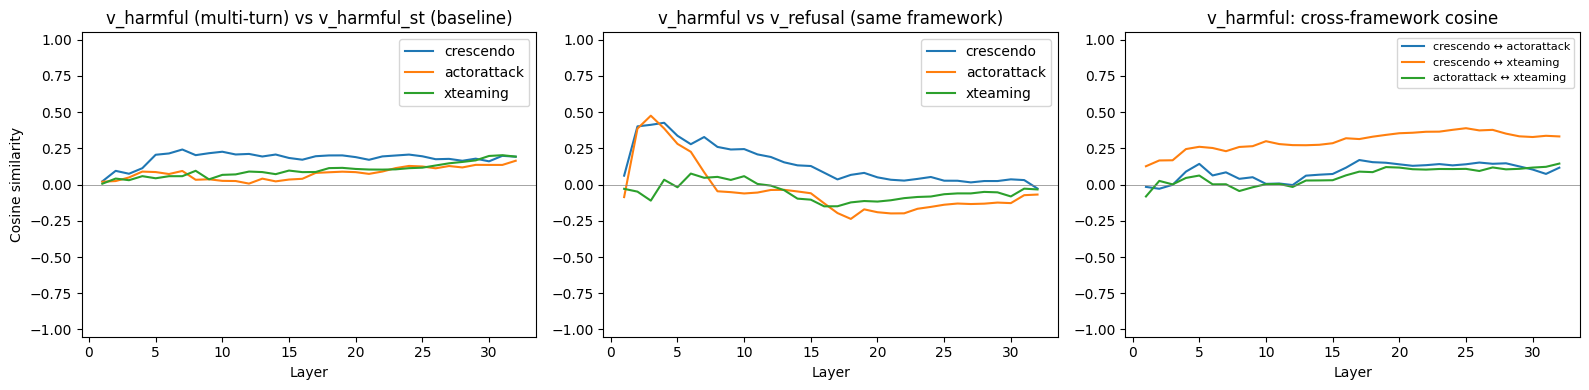

Saved figures/04_direction_cosines.png


In [8]:
# ── Direction cosine similarities across layers — all options ───────────────
#
# One figure per centroid option (A / B / C-early / C-late), each 1×3:
#   panel 1: v_harmful[opt] (multi-turn) vs v_harmful_st (single-turn)
#   panel 2: v_harmful[opt] vs v_refusal[opt] (same framework)
#   panel 3: cross-framework cosine of v_harmful[opt]

def cosine_per_layer(va, vb):
    return (va * vb).sum(axis=-1)

layers = np.arange(1, N_LAYERS + 1)
FW_PAIRS = [('crescendo', 'actorattack'), ('crescendo', 'xteaming'), ('actorattack', 'xteaming')]

for opt_name in OPTION_FNS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    for fw in FRAMEWORKS:
        ax.plot(layers, cosine_per_layer(v_harmful_opts[fw][opt_name], v_harmful_st), label=fw)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel('Cosine similarity')
    ax.set_title(f'v_harmful vs v_harmful_st (single-turn baseline)')
    ax.legend(); ax.set_ylim(-1.05, 1.05)

    ax = axes[1]
    for fw in FRAMEWORKS:
        ax.plot(layers, cosine_per_layer(v_harmful_opts[fw][opt_name], v_refusal_opts[fw][opt_name]), label=fw)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Layer')
    ax.set_title(f'v_harmful vs v_refusal (same framework)')
    ax.legend(); ax.set_ylim(-1.05, 1.05)

    ax = axes[2]
    for fa, fb in FW_PAIRS:
        ax.plot(layers, cosine_per_layer(v_harmful_opts[fa][opt_name], v_harmful_opts[fb][opt_name]),
                label=f'{fa} vs {fb}')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Layer')
    ax.set_title('v_harmful: cross-framework cosine')
    ax.legend(fontsize=8); ax.set_ylim(-1.05, 1.05)

    slug = opt_name.replace('-', '').lower()
    plt.suptitle(f'Direction cosines — Option {opt_name}', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/04_direction_cosines_opt{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved 04_direction_cosines_opt{slug}.png')


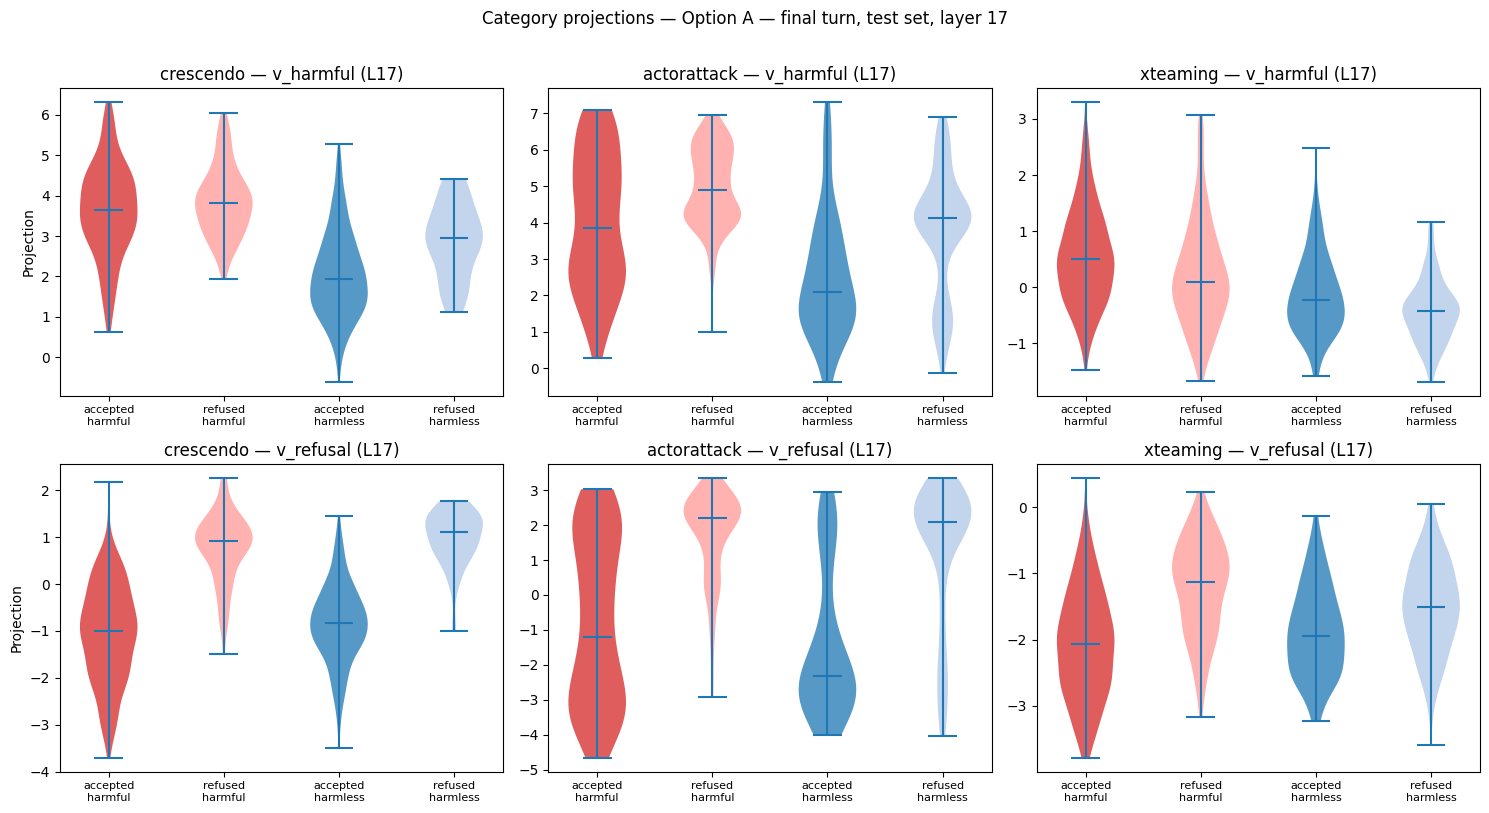

Saved 04_projections_opta.png


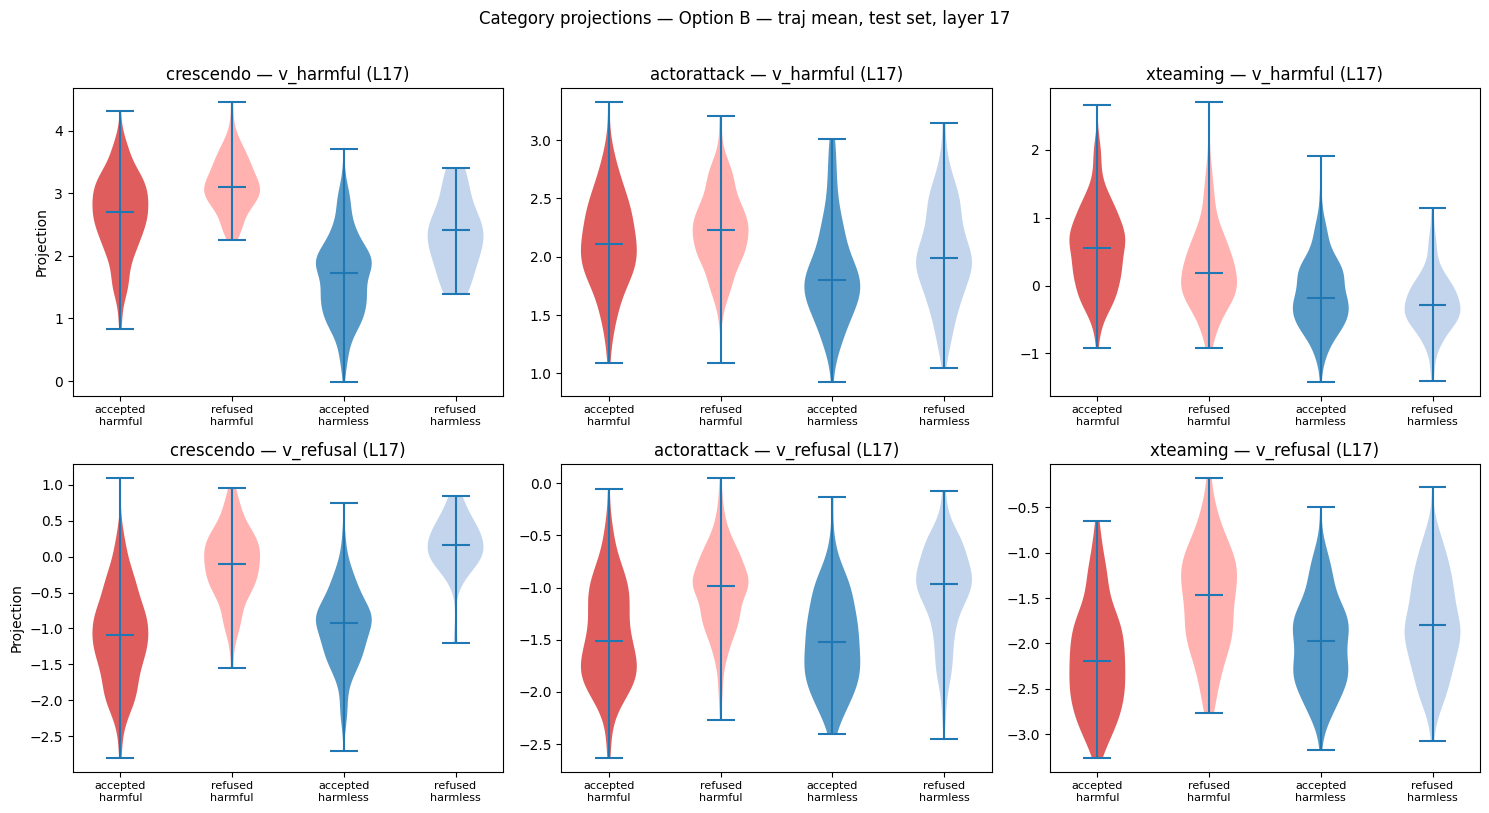

Saved 04_projections_optb.png


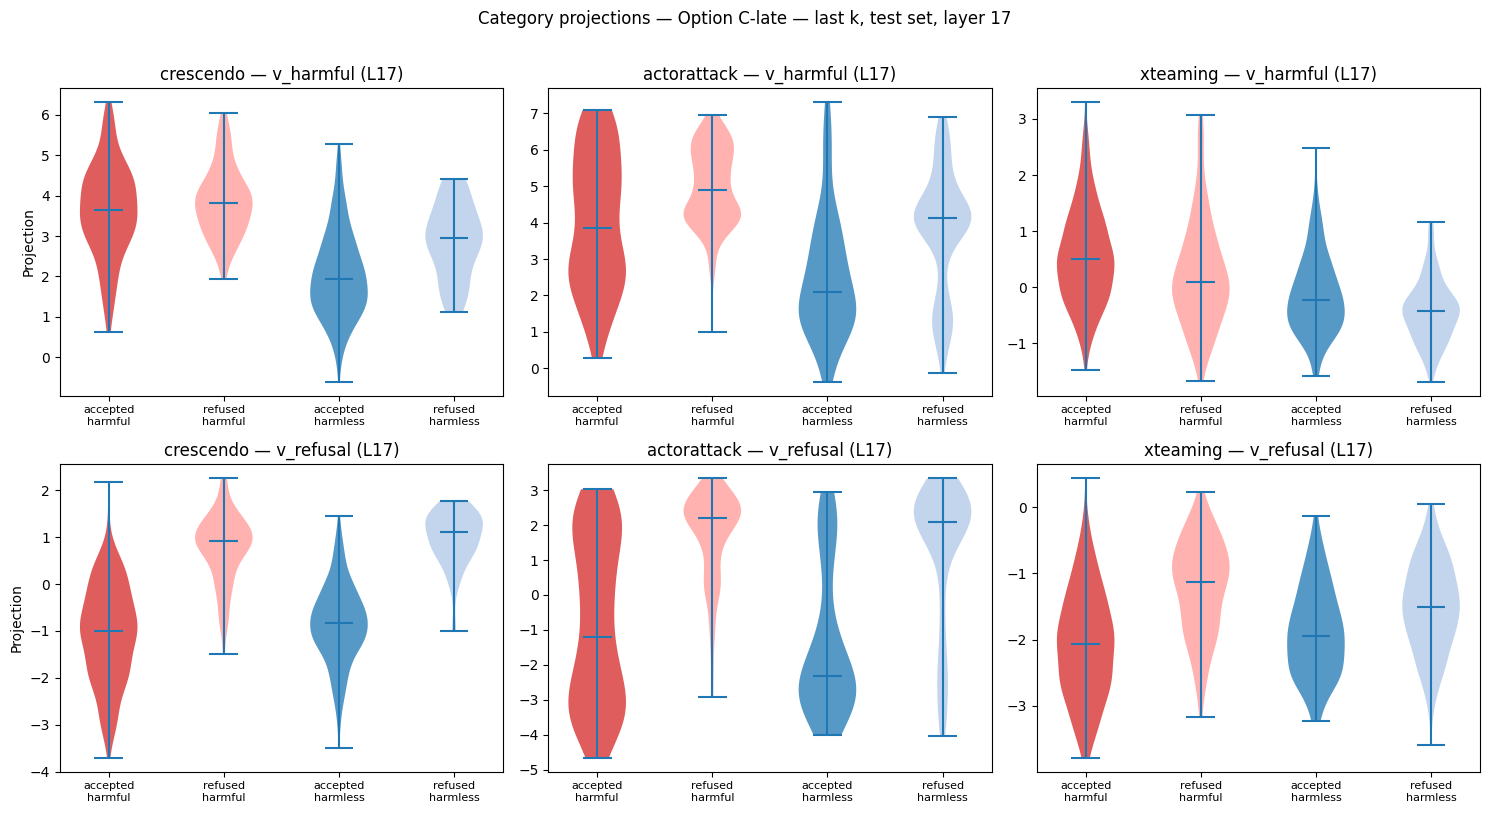

Saved 04_projections_optclate.png


In [9]:
# ── Category projections — all options, matched direction + extraction ───────
#
# For each option: extract test representations WITH that option,
# project onto the direction ALSO computed with that option.
# One 2×3 figure per option (row 0 = v_harmful, row 1 = v_refusal; cols = frameworks).

FOCAL_LAYER = 16

def project(h, direction, layer):
    return (h[:, layer, :].astype(np.float32) @ direction[layer].astype(np.float32))


for opt_name, opt_fn in OPTION_FNS.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for col, fw in enumerate(FRAMEWORKS):
        h_harm_te,  m_harm_te  = opt_fn(traj[(fw,'harmful')]['h_inst'], traj[(fw,'harmful')]['meta'], data_split='test')
        h_beni_te,  m_beni_te  = opt_fn(traj[(fw,'benign' )]['h_inst'], traj[(fw,'benign' )]['meta'], data_split='test')
        hp_harm_te, _          = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'], data_split='test')
        hp_beni_te, _          = opt_fn(traj[(fw,'benign' )]['h_post'], traj[(fw,'benign' )]['meta'], data_split='test')

        h_all  = np.concatenate([h_harm_te,  h_beni_te],  axis=0)
        hp_all = np.concatenate([hp_harm_te, hp_beni_te], axis=0)
        m_all  = pd.concat([m_harm_te, m_beni_te], ignore_index=True)

        # use direction computed with the SAME option
        proj_h = project(h_all,  v_harmful_opts[fw][opt_name], FOCAL_LAYER)
        proj_r = project(hp_all, v_refusal_opts[fw][opt_name], FOCAL_LAYER)

        cats = ['accepted_harmful','refused_harmful','accepted_harmless','refused_harmless']
        for row_idx, (proj, dir_label) in enumerate([(proj_h,'v_harmful'),(proj_r,'v_refusal')]):
            ax = axes[row_idx, col]
            valid = [(proj[m_all['category']==c], c) for c in cats if (m_all['category']==c).any()]
            if valid:
                parts = ax.violinplot([d for d,_ in valid], positions=range(len(valid)), showmedians=True)
                for pc, (_,c) in zip(parts['bodies'], valid):
                    pc.set_facecolor(CATEGORY_COLORS[c]); pc.set_alpha(0.75)
                ax.set_xticks(range(len(valid)))
                ax.set_xticklabels([c.replace('_','\n') for _,c in valid], fontsize=8)
            ax.set_title(f'{fw} — {dir_label} (L{FOCAL_LAYER+1})')
            if col == 0: ax.set_ylabel('Projection')

    slug = opt_name.replace('-','').lower()
    plt.suptitle(f'Category projections — Option {opt_name} (matched direction + extraction), layer {FOCAL_LAYER+1}', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/04_projections_opt{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved 04_projections_opt{slug}.png')


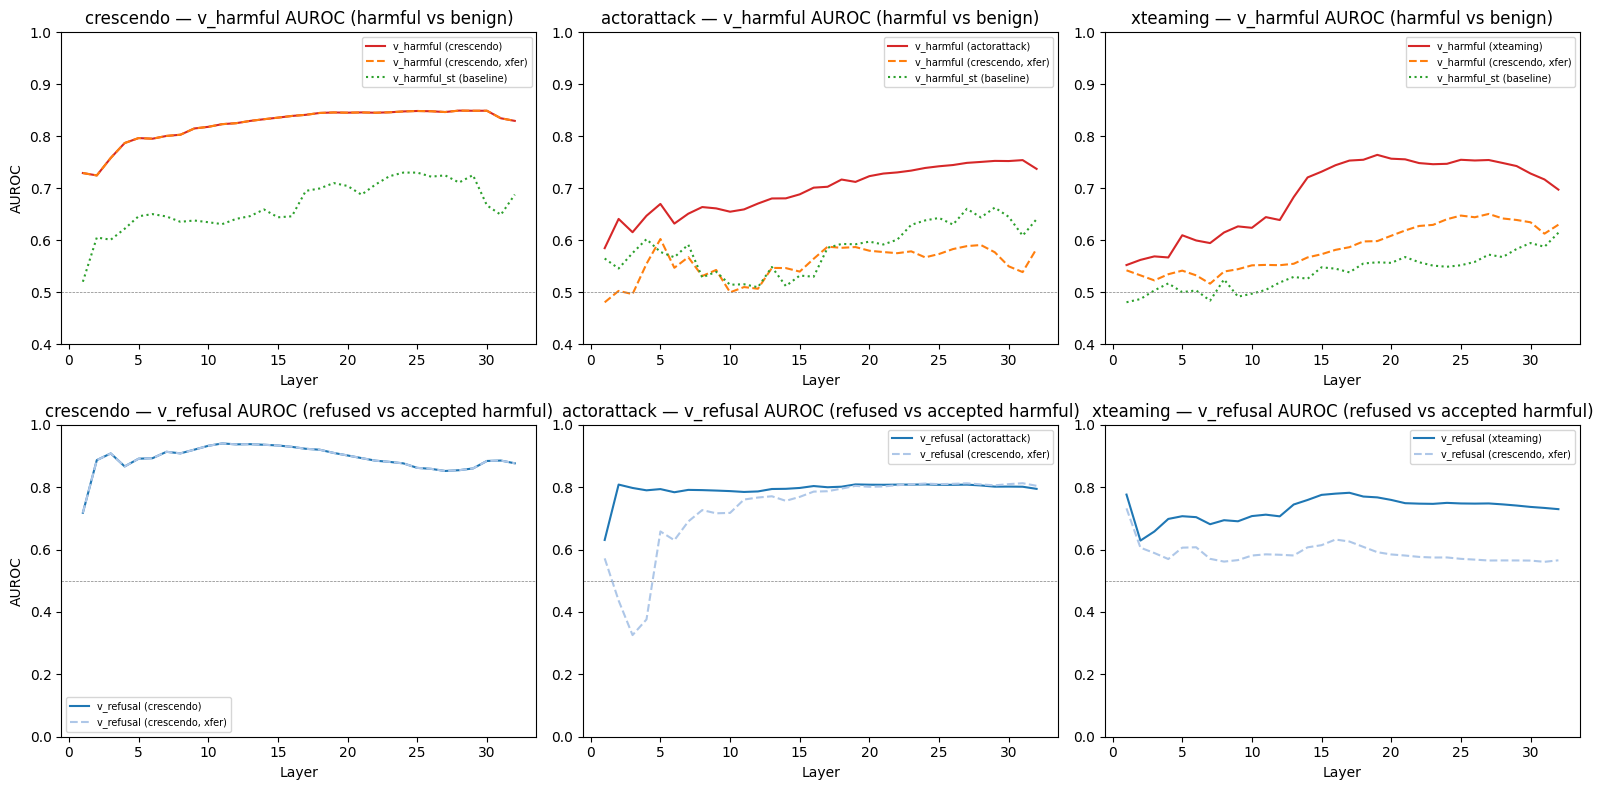

Saved figures/04_auroc_per_layer.png


In [10]:
# ── AUROC per layer — all options ────────────────────────────────────────────
#
# One 2×3 figure per centroid option.
#   row 0: v_harmful AUROC — harmful vs benign (test set)
#   row 1: v_refusal AUROC — refused_harmful vs accepted_harmful (test set)
# Direction and test extraction both use the same option.
# Each subplot also shows the single-turn baseline (v_harmful_st, row 0 only)
# and the crescendo-direction transfer (dashed) for reference.

def auroc_per_layer(h_pos, h_neg, direction):
    aucs = []
    for l in range(N_LAYERS):
        p_proj = h_pos[:, l, :].astype(np.float32) @ direction[l].astype(np.float32)
        n_proj = h_neg[:, l, :].astype(np.float32) @ direction[l].astype(np.float32)
        scores = np.concatenate([p_proj, n_proj])
        labels = np.concatenate([np.ones(len(p_proj)), np.zeros(len(n_proj))])
        try:
            aucs.append(roc_auc_score(labels, scores))
        except ValueError:
            aucs.append(float('nan'))
    return np.array(aucs)


for opt_name, opt_fn in OPTION_FNS.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for col, fw in enumerate(FRAMEWORKS):
        # Test-set extraction with this option
        h_harm_te, _ = opt_fn(traj[(fw,'harmful')]['h_inst'], traj[(fw,'harmful')]['meta'], data_split='test')
        h_beni_te, _ = opt_fn(traj[(fw,'benign' )]['h_inst'], traj[(fw,'benign' )]['meta'], data_split='test')
        hp_ref_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='refused_harmful')
        hp_acc_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='accepted_harmful')

        # Row 0: v_harmful — harmful vs benign
        ax = axes[0, col]
        auc_own = auroc_per_layer(h_harm_te, h_beni_te, v_harmful_opts[fw][opt_name])
        auc_xfr = auroc_per_layer(h_harm_te, h_beni_te, v_harmful_opts['crescendo'][opt_name])
        auc_st  = auroc_per_layer(h_harm_te, h_beni_te, v_harmful_st)
        ax.plot(layers, auc_own, color='#d62728', label=f'v_harmful {fw}')
        ax.plot(layers, auc_xfr, color='#ff7f0e', ls='--', label='crescendo xfer')
        ax.plot(layers, auc_st,  color='#2ca02c', ls=':',  label='single-turn baseline')
        ax.axhline(0.5, color='gray', lw=0.5, ls='--')
        ax.set_ylim(0.4, 1.0); ax.set_xlabel('Layer')
        ax.set_title(f'{fw} — v_harmful (harmful vs benign)')
        ax.legend(fontsize=7)
        if col == 0: ax.set_ylabel('AUROC')

        # Row 1: v_refusal — refused vs accepted harmful
        ax = axes[1, col]
        auc_own_r = auroc_per_layer(hp_ref_te, hp_acc_te, v_refusal_opts[fw][opt_name])
        auc_xfr_r = auroc_per_layer(hp_ref_te, hp_acc_te, v_refusal_opts['crescendo'][opt_name])
        ax.plot(layers, auc_own_r, color='#1f77b4', label=f'v_refusal {fw}')
        ax.plot(layers, auc_xfr_r, color='#aec7e8', ls='--', label='crescendo xfer')
        ax.axhline(0.5, color='gray', lw=0.5, ls='--')
        ax.set_ylim(0.0, 1.0); ax.set_xlabel('Layer')
        ax.set_title(f'{fw} — v_refusal (refused vs accepted)')
        ax.legend(fontsize=7)
        if col == 0: ax.set_ylabel('AUROC')

    slug = opt_name.replace('-','').lower()
    plt.suptitle(f'AUROC per layer — Option {opt_name} (matched direction + extraction)', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/04_auroc_opt{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved 04_auroc_opt{slug}.png')


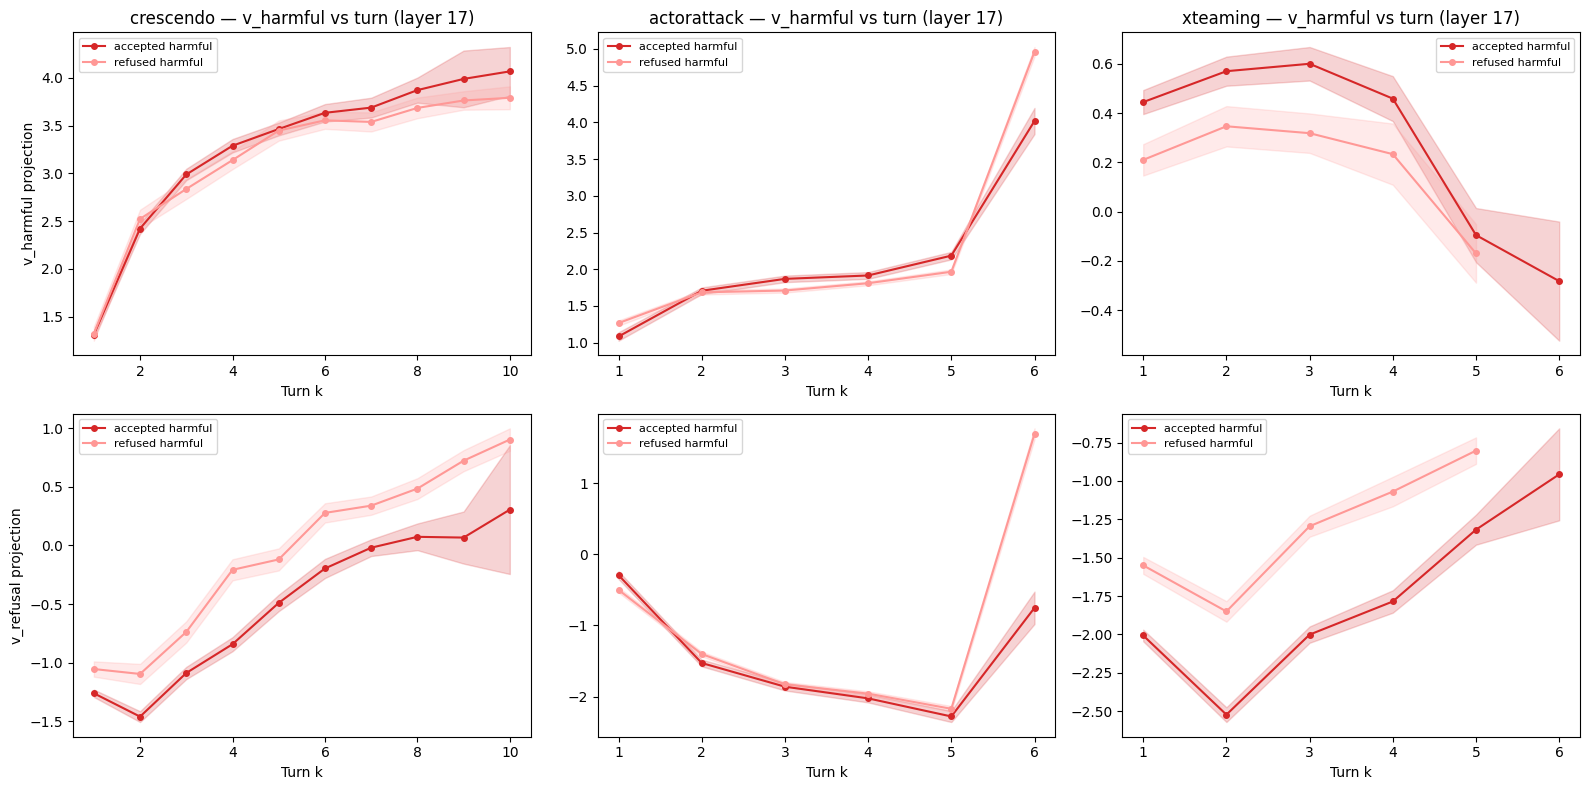

Saved figures/04_trajectory_projections.png


In [11]:
# ── Trajectory projections — all options ────────────────────────────────────
#
# For each option: the DIRECTION is computed with that option, but the
# trajectory itself always shows all individual turns (no extraction step —
# we index the raw traj array directly). One 2×3 figure per option.

for opt_name in OPTION_FNS:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for col, fw in enumerate(FRAMEWORKS):
        meta_h    = traj[(fw, 'harmful')]['meta']
        test_meta = meta_h[meta_h['data_split'] == 'test'].copy()

        v_harm_dir = v_harmful_opts[fw][opt_name][FOCAL_LAYER]
        v_ref_dir  = v_refusal_opts[fw][opt_name][FOCAL_LAYER]

        for row_idx, (direction, h_key, ylabel) in enumerate([
            (v_harm_dir, 'h_inst', 'v_harmful projection'),
            (v_ref_dir,  'h_post', 'v_refusal projection'),
        ]):
            ax   = axes[row_idx, col]
            h_arr = traj[(fw, 'harmful')][h_key]

            for cat, color in [('accepted_harmful','#d62728'),('refused_harmful','#ff9896')]:
                sub = test_meta[test_meta['category'] == cat]
                if sub.empty: continue
                max_turn = int(sub['turn_k'].max())
                means, sems, turn_ns = [], [], []
                for k in range(1, max_turn + 1):
                    rows_k = sub[sub['turn_k'] == k]
                    if len(rows_k) < 3: break
                    pos  = meta_h.index.get_indexer(rows_k.index)
                    proj = h_arr[pos][:, FOCAL_LAYER, :].astype(np.float32) @ direction
                    means.append(proj.mean())
                    sems.append(proj.std() / np.sqrt(len(proj)))
                    turn_ns.append(k)
                means, sems = np.array(means), np.array(sems)
                ax.plot(turn_ns, means, color=color, label=cat.replace('_',' '), marker='o', ms=4)
                ax.fill_between(turn_ns, means-sems, means+sems, color=color, alpha=0.2)

            ax.set_xlabel('Turn k')
            if row_idx == 0:
                ax.set_title(f'{fw} — v_harmful vs turn (L{FOCAL_LAYER+1})')
            else:
                ax.set_title(f'{fw} — v_refusal vs turn (L{FOCAL_LAYER+1})')
            if col == 0: ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)

    slug = opt_name.replace('-','').lower()
    plt.suptitle(f'Trajectory projections — Option {opt_name} direction, layer {FOCAL_LAYER+1}', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/04_trajectory_opt{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved 04_trajectory_opt{slug}.png')


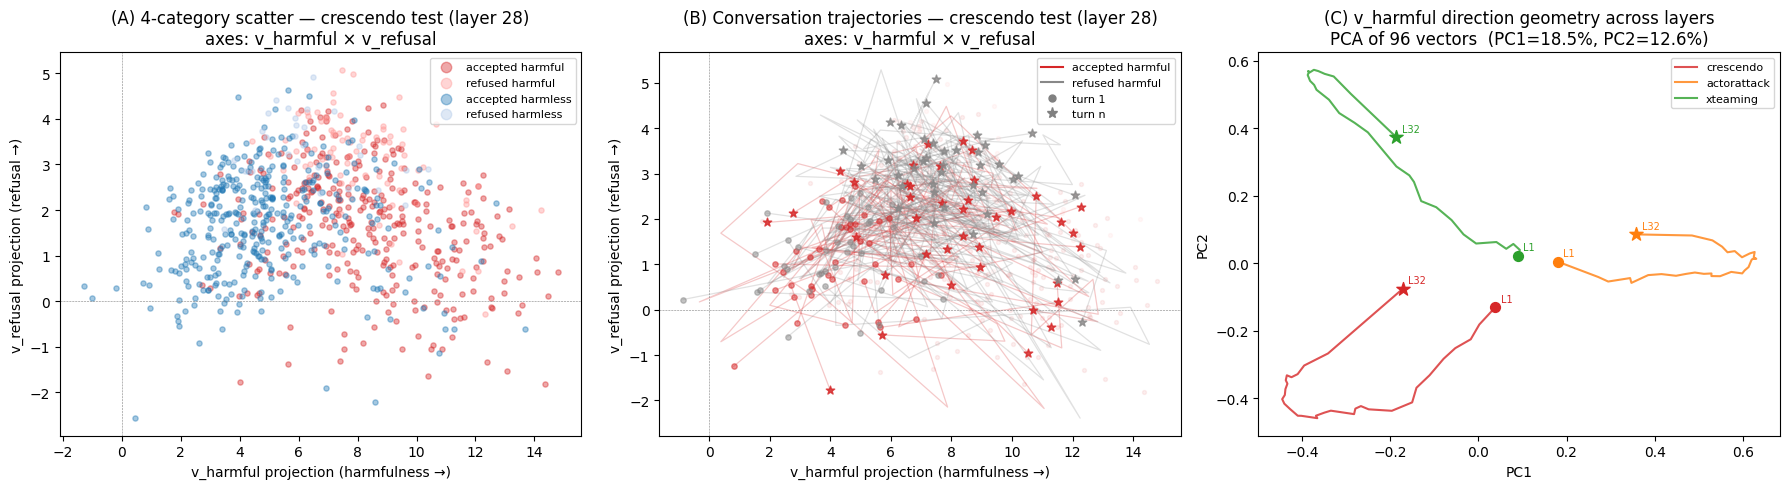

Saved figures/04_pca.png


In [12]:
# ── PCA / direction-plane analysis ───────────────────────────────────────────
#
# Three panels:
#
#  (A) v_harmful × v_refusal scatter — project h_inst onto the 2D plane spanned
#      by the two direction vectors. x = harmfulness, y = refusal. The four
#      behavioral categories should separate cleanly here.
#
#  (B) Trajectory paths in v_harmful × v_refusal plane — per-conversation paths
#      from turn 1 (dot) to turn n (star). Accepted conversations should move
#      right (more harmful) and down (less refusal) as attack context builds.
#
#  (C) Cross-framework direction geometry — PCA of v_harmful vectors across all
#      32 layers × 3 frameworks. Curves converging = shared late-layer subspace.

from sklearn.decomposition import PCA

PCA_LAYER = 27   # 0-indexed = layer 28, peak AUROC for v_harmful

# Direction vectors at PCA_LAYER (unit vectors)
v_h = v_harmful["crescendo"][PCA_LAYER].astype(np.float32)   # (4096,)
v_r = v_refusal["crescendo"][PCA_LAYER].astype(np.float32)   # (4096,)

def project_2d(h, v_harm, v_ref):
    """Project (N, 4096) onto (harmfulness, refusal) axes. Returns (N, 2)."""
    h = h.astype(np.float32)
    return np.stack([h @ v_harm, h @ v_ref], axis=1)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: 4-category scatter ───────────────────────────────────────────────
ax = axes[0]
h_te_harm, m_te_harm = option_a(
    traj[("crescendo", "harmful")]["h_inst"], traj[("crescendo", "harmful")]["meta"],
    data_split="test",
)
h_te_beni, m_te_beni = option_a(
    traj[("crescendo", "benign")]["h_inst"], traj[("crescendo", "benign")]["meta"],
    data_split="test",
)
h_all = np.concatenate([h_te_harm[:, PCA_LAYER, :], h_te_beni[:, PCA_LAYER, :]], axis=0)
m_all = pd.concat([m_te_harm, m_te_beni], ignore_index=True)
coords = project_2d(h_all, v_h, v_r)

cats_ordered = ["accepted_harmful", "refused_harmful", "accepted_harmless", "refused_harmless"]
for cat in cats_ordered:
    mask = m_all["category"] == cat
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=CATEGORY_COLORS[cat], label=cat.replace("_", " "),
               alpha=0.4, s=14, rasterized=True)

ax.set_xlabel("v_harmful projection (harmfulness →)")
ax.set_ylabel("v_refusal projection (refusal →)")
ax.set_title(f"(A) 4-category scatter — crescendo test (layer {PCA_LAYER+1})\n"
             f"axes: v_harmful × v_refusal")
ax.legend(fontsize=8, markerscale=2)
ax.axhline(0, color="gray", lw=0.4, ls="--")
ax.axvline(0, color="gray", lw=0.4, ls="--")

# ── Panel B: trajectory paths in v_harmful × v_refusal plane ─────────────────
ax = axes[1]
# Faint background
for cat in ["accepted_harmful", "refused_harmful"]:
    mask = m_all["category"] == cat
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=CATEGORY_COLORS[cat], alpha=0.07, s=8, rasterized=True)

np.random.seed(42)
meta_traj = traj[("crescendo", "harmful")]["meta"]
h_traj    = traj[("crescendo", "harmful")]["h_inst"]
test_traj = meta_traj[meta_traj["data_split"] == "test"]

for cat, color, n_sample in [("accepted_harmful", "#d62728", 40), ("refused_harmful", "#888888", 40)]:
    convs = test_traj[test_traj["category"] == cat]["conversation_id"].unique()
    if len(convs) > n_sample:
        convs = np.random.choice(convs, n_sample, replace=False)
    for cid in convs:
        rows = test_traj[test_traj["conversation_id"] == cid].sort_values("turn_k")
        if len(rows) < 2:
            continue
        pos  = meta_traj.index.get_indexer(rows.index)
        pts  = project_2d(h_traj[pos][:, PCA_LAYER, :], v_h, v_r)
        ax.plot(pts[:, 0], pts[:, 1], color=color, alpha=0.25, lw=0.9)
        ax.scatter(pts[0,  0], pts[0,  1], color=color, s=15, zorder=3, alpha=0.5)
        ax.scatter(pts[-1, 0], pts[-1, 1], color=color, s=40, marker="*", zorder=4, alpha=0.8)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], color="#d62728", lw=1.5, label="accepted harmful"),
    Line2D([0], [0], color="#888888", lw=1.5, label="refused harmful"),
    Line2D([0], [0], marker="o",  color="gray", ms=5, lw=0, label="turn 1"),
    Line2D([0], [0], marker="*",  color="gray", ms=8, lw=0, label="turn n"),
]
ax.legend(handles=legend_els, fontsize=8)
ax.set_xlabel("v_harmful projection (harmfulness →)")
ax.set_ylabel("v_refusal projection (refusal →)")
ax.set_title(f"(B) Conversation trajectories — crescendo test (layer {PCA_LAYER+1})\n"
             f"axes: v_harmful × v_refusal")
ax.axhline(0, color="gray", lw=0.4, ls="--")
ax.axvline(0, color="gray", lw=0.4, ls="--")

# ── Panel C: cross-framework direction geometry (PCA of direction vectors) ────
ax = axes[2]
fw_colors = {"crescendo": "#d62728", "actorattack": "#ff7f0e", "xteaming": "#2ca02c"}

dir_vecs, dir_fw = [], []
for fw in FRAMEWORKS:
    for l in range(N_LAYERS):
        dir_vecs.append(v_harmful[fw][l])
        dir_fw.append(fw)

dir_vecs   = np.stack(dir_vecs).astype(np.float32)
pca_dir    = PCA(n_components=2, random_state=42)
dir_coords = pca_dir.fit_transform(dir_vecs)

for fw in FRAMEWORKS:
    mask = np.array(dir_fw) == fw
    pts  = dir_coords[mask]
    ax.plot(pts[:, 0], pts[:, 1], color=fw_colors[fw], lw=1.5, label=fw, alpha=0.8)
    ax.scatter(pts[0,  0], pts[0,  1], color=fw_colors[fw], s=50,  zorder=5)
    ax.scatter(pts[-1, 0], pts[-1, 1], color=fw_colors[fw], s=100, marker="*", zorder=5)
    ax.annotate("L1",  (pts[0, 0],  pts[0, 1]),  fontsize=7, color=fw_colors[fw],
                xytext=(4, 4), textcoords="offset points")
    ax.annotate("L32", (pts[-1, 0], pts[-1, 1]), fontsize=7, color=fw_colors[fw],
                xytext=(4, 4), textcoords="offset points")

ax.set_title(
    f"(C) v_harmful direction geometry across layers\n"
    f"PCA of {len(dir_vecs)} vectors  "
    f"(PC1={pca_dir.explained_variance_ratio_[0]*100:.1f}%, "
    f"PC2={pca_dir.explained_variance_ratio_[1]*100:.1f}%)"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/04_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/04_pca.png")

Computed per-category directions for 10 categories


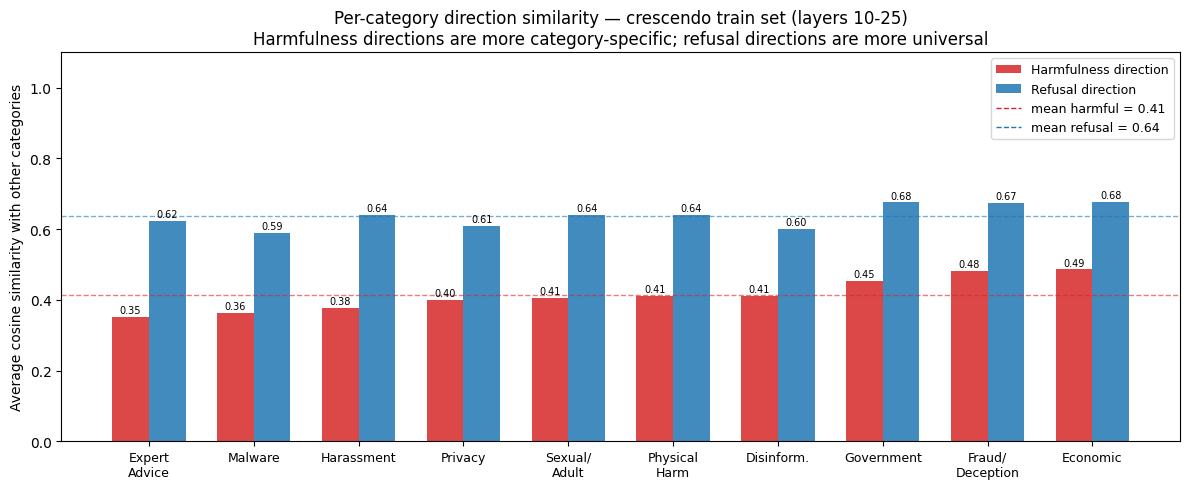

Mean harmful cosine: 0.414
Mean refusal cosine: 0.637
Saved figures/04_category_direction_cosines.png


In [13]:
# ── Per-category direction cosine similarity (Zhao et al. Fig 14a / Fig 9a) ──
#
# Build pair_id → JBB harm category mapping from single-turn metadata.
# Note: traj["category"] is the behavioral label (accepted_harmful etc.) set in
# cell 3 — not the JBB harm category. Use pair_to_cat lookup directly.
pair_to_cat = dict(zip(
    st["harmful"]["meta"]["pair_id"],
    st["harmful"]["meta"]["category"],
))
categories  = sorted(set(pair_to_cat.values()))
MIDDLE_LAYERS = list(range(9, 25))   # 0-indexed layers 10-25

FW = "crescendo"


def compute_per_category_directions(framework):
    h_harm_all, m_harm_all = option_a(
        traj[(framework, "harmful")]["h_inst"],
        traj[(framework, "harmful")]["meta"],
        data_split="train",
    )
    h_beni_all, m_beni_all = option_a(
        traj[(framework, "benign")]["h_inst"],
        traj[(framework, "benign")]["meta"],
        data_split="train",
    )
    hp_harm_all, _ = option_a(
        traj[(framework, "harmful")]["h_post"],
        traj[(framework, "harmful")]["meta"],
        data_split="train",
    )

    # Map pair_id → JBB category for returned subsets
    harm_jbb = m_harm_all["pair_id"].map(pair_to_cat)
    beni_jbb = m_beni_all["pair_id"].map(pair_to_cat)

    v_harm_cat, v_ref_cat = {}, {}
    for cat in categories:
        mask_h = (harm_jbb == cat).values
        mask_b = (beni_jbb == cat).values
        if mask_h.sum() == 0 or mask_b.sum() == 0:
            continue
        mu_h = h_harm_all[mask_h].mean(axis=0)
        mu_b = h_beni_all[mask_b].mean(axis=0)
        diff = mu_h - mu_b
        norms = np.linalg.norm(diff, axis=-1, keepdims=True)
        v_harm_cat[cat] = diff / (norms + 1e-12)

        mask_ref = ((harm_jbb == cat) & ~m_harm_all["attack_success"]).values
        mask_acc = ((harm_jbb == cat) &  m_harm_all["attack_success"]).values
        if mask_ref.sum() == 0 or mask_acc.sum() == 0:
            v_ref_cat[cat] = v_harm_cat[cat] * 0
            continue
        mu_ref = hp_harm_all[mask_ref].mean(axis=0)
        mu_acc = hp_harm_all[mask_acc].mean(axis=0)
        diff_r = mu_ref - mu_acc
        norms_r = np.linalg.norm(diff_r, axis=-1, keepdims=True)
        v_ref_cat[cat] = diff_r / (norms_r + 1e-12)

    return v_harm_cat, v_ref_cat


def avg_cross_cat_cosine(direction_dict, layers):
    cats = list(direction_dict.keys())
    result = {}
    for c in cats:
        sims = []
        for c2 in cats:
            if c2 == c:
                continue
            cos_layers = [float(np.dot(direction_dict[c][l], direction_dict[c2][l]))
                          for l in layers]
            sims.append(np.mean(cos_layers))
        result[c] = float(np.mean(sims))
    return result


v_harm_cat, v_ref_cat = compute_per_category_directions(FW)
print(f"Computed per-category directions for {len(v_harm_cat)} categories")

cos_harmful = avg_cross_cat_cosine(v_harm_cat, MIDDLE_LAYERS)
cos_refusal = avg_cross_cat_cosine(v_ref_cat,  MIDDLE_LAYERS)

# ── Plot ──────────────────────────────────────────────────────────────────────
short = {
    "Disinformation":               "Disinform.",
    "Economic harm":                "Economic",
    "Expert advice":                "Expert\nAdvice",
    "Fraud/Deception":              "Fraud/\nDeception",
    "Government decision-making":   "Government",
    "Harassment/Discrimination":    "Harassment",
    "Malware/Hacking":              "Malware",
    "Physical harm":                "Physical\nHarm",
    "Privacy":                      "Privacy",
    "Sexual/Adult content":         "Sexual/\nAdult",
}

cats_sorted = sorted(categories, key=lambda c: cos_harmful[c])
labels = [short.get(c, c) for c in cats_sorted]
x = np.arange(len(cats_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_h = ax.bar(x - width/2, [cos_harmful[c] for c in cats_sorted],
                width, label="Harmfulness direction", color="#d62728", alpha=0.85)
bars_r = ax.bar(x + width/2, [cos_refusal[c] for c in cats_sorted],
                width, label="Refusal direction", color="#1f77b4", alpha=0.85)

for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)
for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Average cosine similarity with other categories")
ax.set_title(
    f"Per-category direction similarity — {FW} train set "
    f"(layers {MIDDLE_LAYERS[0]+1}-{MIDDLE_LAYERS[-1]+1})\n"
    "Harmfulness directions are more category-specific; refusal directions are more universal"
)
ax.set_ylim(0.0, 1.1)
mean_h = np.mean(list(cos_harmful.values()))
mean_r = np.mean(list(cos_refusal.values()))
ax.axhline(mean_h, color="#d62728", lw=1, ls="--", alpha=0.6)
ax.axhline(mean_r, color="#1f77b4", lw=1, ls="--", alpha=0.6)
ax.legend([
    bars_h, bars_r,
    plt.Line2D([0],[0],color="#d62728",lw=1,ls="--"),
    plt.Line2D([0],[0],color="#1f77b4",lw=1,ls="--"),
], [
    "Harmfulness direction", "Refusal direction",
    f"mean harmful = {mean_h:.2f}",
    f"mean refusal = {mean_r:.2f}",
], fontsize=9)

plt.tight_layout()
plt.savefig("../figures/04_category_direction_cosines.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean harmful cosine: {mean_h:.3f}")
print(f"Mean refusal cosine: {mean_r:.3f}")
print("Saved figures/04_category_direction_cosines.png")


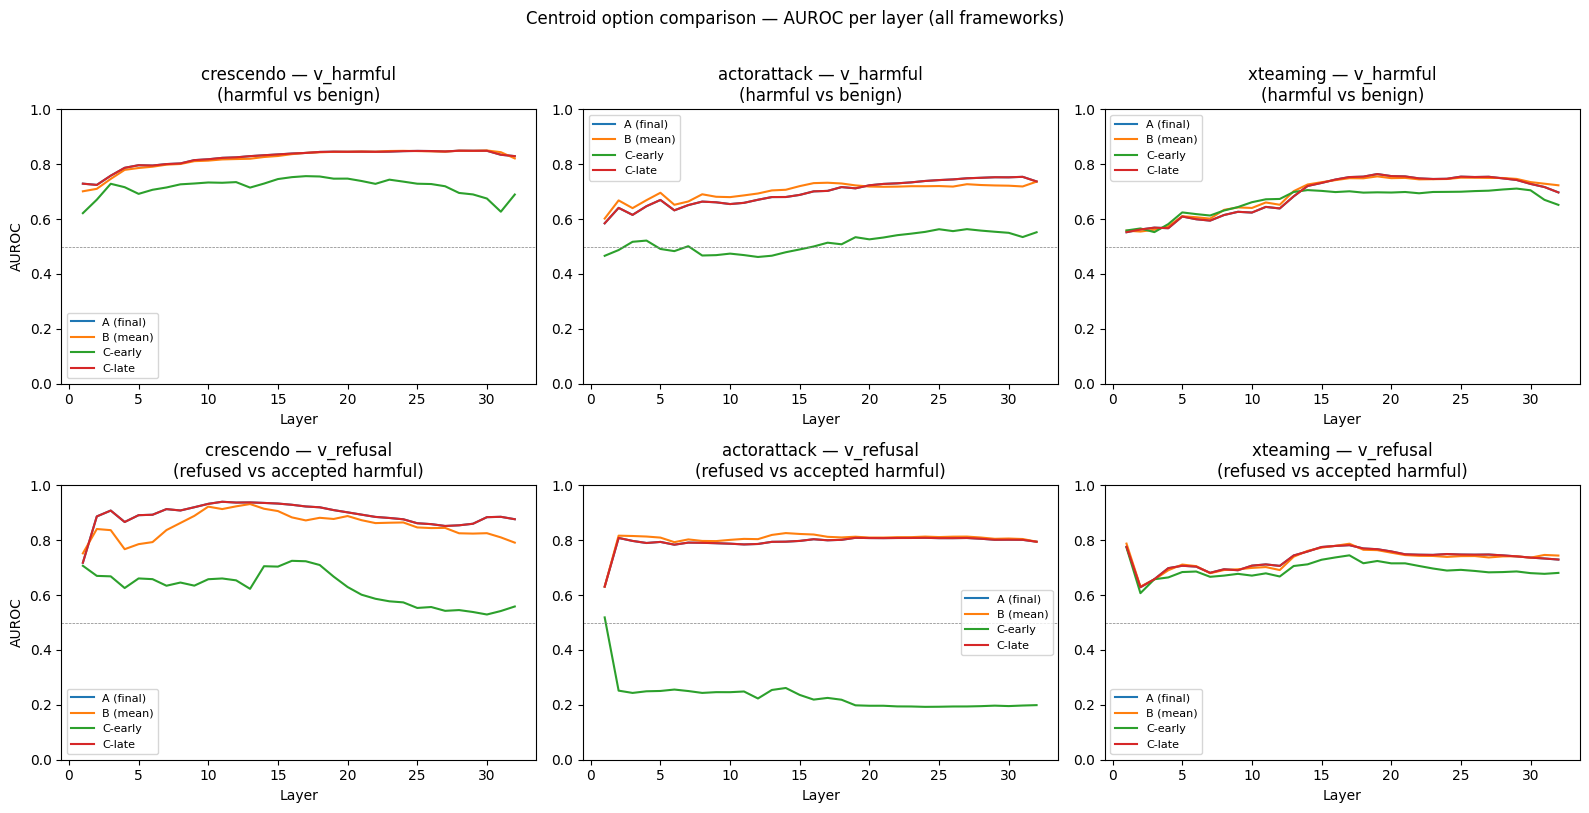

Saved figures/04_option_comparison.png


In [15]:
# ── Option comparison overlay — quick visual summary ────────────────────────
#
# Overlay all 4 option AUROC curves on the same subplot to compare peak
# values and layer profiles side by side. 2×3 grid: row = direction, col = fw.
# Direction and test extraction are matched for each option.

OPT_COLORS = {'A': '#1f77b4', 'B': '#ff7f0e', 'C-early': '#2ca02c', 'C-late': '#d62728'}
OPT_LS     = {'A': '-',       'B': '--',       'C-early': ':',        'C-late': '-.'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, fw in enumerate(FRAMEWORKS):
    for opt_name, opt_fn in OPTION_FNS.items():
        h_harm_te, _ = opt_fn(traj[(fw,'harmful')]['h_inst'], traj[(fw,'harmful')]['meta'], data_split='test')
        h_beni_te, _ = opt_fn(traj[(fw,'benign' )]['h_inst'], traj[(fw,'benign' )]['meta'], data_split='test')
        hp_ref_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='refused_harmful')
        hp_acc_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='accepted_harmful')

        auc_h = auroc_per_layer(h_harm_te, h_beni_te,  v_harmful_opts[fw][opt_name])
        auc_r = auroc_per_layer(hp_ref_te, hp_acc_te,  v_refusal_opts[fw][opt_name])

        axes[0, col].plot(layers, auc_h, color=OPT_COLORS[opt_name],
                          ls=OPT_LS[opt_name], label=f'Opt {opt_name}')
        axes[1, col].plot(layers, auc_r, color=OPT_COLORS[opt_name],
                          ls=OPT_LS[opt_name], label=f'Opt {opt_name}')

    for row_idx, (task, ylbl) in enumerate([
        ('v_harmful (harmful vs benign)', 'AUROC'),
        ('v_refusal (refused vs accepted)', 'AUROC'),
    ]):
        ax = axes[row_idx, col]
        ax.axhline(0.5, color='gray', lw=0.5, ls='--')
        ax.set_ylim(0.4, 1.0); ax.set_xlabel('Layer')
        ax.set_title(f'{fw}\n{task}')
        ax.legend(fontsize=8)
        if col == 0: ax.set_ylabel(ylbl)

plt.suptitle('Option A/B/C-early/C-late AUROC overlay (matched direction + extraction)', y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_option_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/04_option_comparison.png')


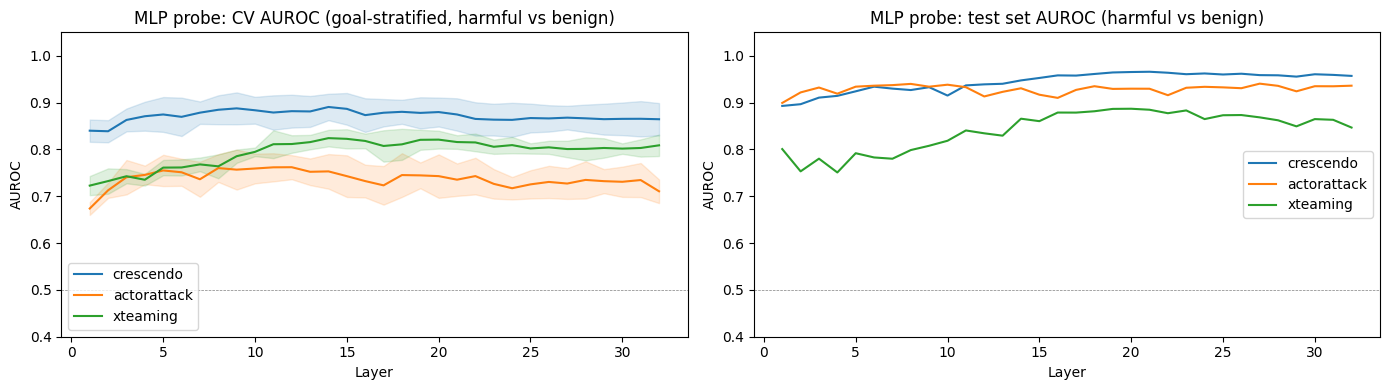

Saved figures/04_mlp_probe.png


In [16]:
# ── MLP probe — goal-stratified CV ───────────────────────────────────────────
#
# Task: binary classification — harmful (1) vs benign (0), final turn (Option A)
# Stratification: pair_id as group → GroupKFold(n_splits=5)
#   prevents probe from memorising topic; tests goal-level generalisation.
#
# Train on train set. Reports mean AUROC ± std across folds per layer.
# Then evaluates on the held-out test set using a full-train-set-fitted probe.

def mlp_probe_auroc(framework, n_splits=5):
    """Returns (mean_auc_cv, std_auc_cv, test_auc) arrays of length N_LAYERS."""
    h_harm_tr, m_harm_tr = option_a(
        traj[(framework, "harmful")]["h_inst"],
        traj[(framework, "harmful")]["meta"],
        data_split="train",
    )
    h_beni_tr, m_beni_tr = option_a(
        traj[(framework, "benign")]["h_inst"],
        traj[(framework, "benign")]["meta"],
        data_split="train",
    )
    h_harm_te, _ = option_a(
        traj[(framework, "harmful")]["h_inst"],
        traj[(framework, "harmful")]["meta"],
        data_split="test",
    )
    h_beni_te, _ = option_a(
        traj[(framework, "benign")]["h_inst"],
        traj[(framework, "benign")]["meta"],
        data_split="test",
    )

    X_tr  = np.concatenate([h_harm_tr, h_beni_tr], axis=0)
    y_tr  = np.concatenate([np.ones(len(h_harm_tr)), np.zeros(len(h_beni_tr))]).astype(int)
    grp   = np.concatenate([m_harm_tr["pair_id"].values, m_beni_tr["pair_id"].values])

    X_te  = np.concatenate([h_harm_te, h_beni_te], axis=0)
    y_te  = np.concatenate([np.ones(len(h_harm_te)), np.zeros(len(h_beni_te))]).astype(int)

    gkf = GroupKFold(n_splits=n_splits)
    mean_cv, std_cv, test_auc = [], [], []

    for layer in tqdm(range(N_LAYERS), desc=f"MLP probe {framework}", leave=False):
        X_l_tr = X_tr[:, layer, :].astype(np.float32)
        X_l_te = X_te[:, layer, :].astype(np.float32)
        fold_aucs = []

        for tr_idx, val_idx in gkf.split(X_l_tr, y_tr, groups=grp):
            scaler = StandardScaler()
            X_f_tr = scaler.fit_transform(X_l_tr[tr_idx])
            X_f_val = scaler.transform(X_l_tr[val_idx])
            if len(np.unique(y_tr[val_idx])) < 2:
                continue
            clf = MLPClassifier(hidden_layer_sizes=(256,), max_iter=200,
                                random_state=42, early_stopping=True)
            clf.fit(X_f_tr, y_tr[tr_idx])
            fold_aucs.append(roc_auc_score(y_tr[val_idx], clf.predict_proba(X_f_val)[:, 1]))

        # Test AUC: fit on full train, eval on held-out test
        scaler_full = StandardScaler()
        clf_full = MLPClassifier(hidden_layer_sizes=(256,), max_iter=200,
                                 random_state=42, early_stopping=True)
        clf_full.fit(scaler_full.fit_transform(X_l_tr), y_tr)
        t_auc = roc_auc_score(y_te, clf_full.predict_proba(scaler_full.transform(X_l_te))[:, 1])

        mean_cv.append(np.mean(fold_aucs) if fold_aucs else float("nan"))
        std_cv.append(np.std(fold_aucs) if fold_aucs else float("nan"))
        test_auc.append(t_auc)

    return np.array(mean_cv), np.array(std_cv), np.array(test_auc)


probe_results = {}
for fw in FRAMEWORKS:
    probe_results[fw] = mlp_probe_auroc(fw)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ax, which in zip(axes, ["cv", "test"]):
    for fw, color in zip(FRAMEWORKS, colors):
        mean_cv, std_cv, test_auc = probe_results[fw]
        if which == "cv":
            ax.plot(layers, mean_cv, label=fw, color=color)
            ax.fill_between(layers, mean_cv - std_cv, mean_cv + std_cv, color=color, alpha=0.15)
        else:
            ax.plot(layers, test_auc, label=fw, color=color)
    ax.axhline(0.5, color="gray", lw=0.5, ls="--")
    ax.set_xlabel("Layer")
    ax.set_ylim(0.4, 1.05)
    title = "MLP probe: CV AUROC (goal-stratified, harmful vs benign)" if which == "cv" \
            else "MLP probe: test set AUROC (harmful vs benign)"
    ax.set_title(title)
    ax.set_ylabel("AUROC")
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/04_mlp_probe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/04_mlp_probe.png")

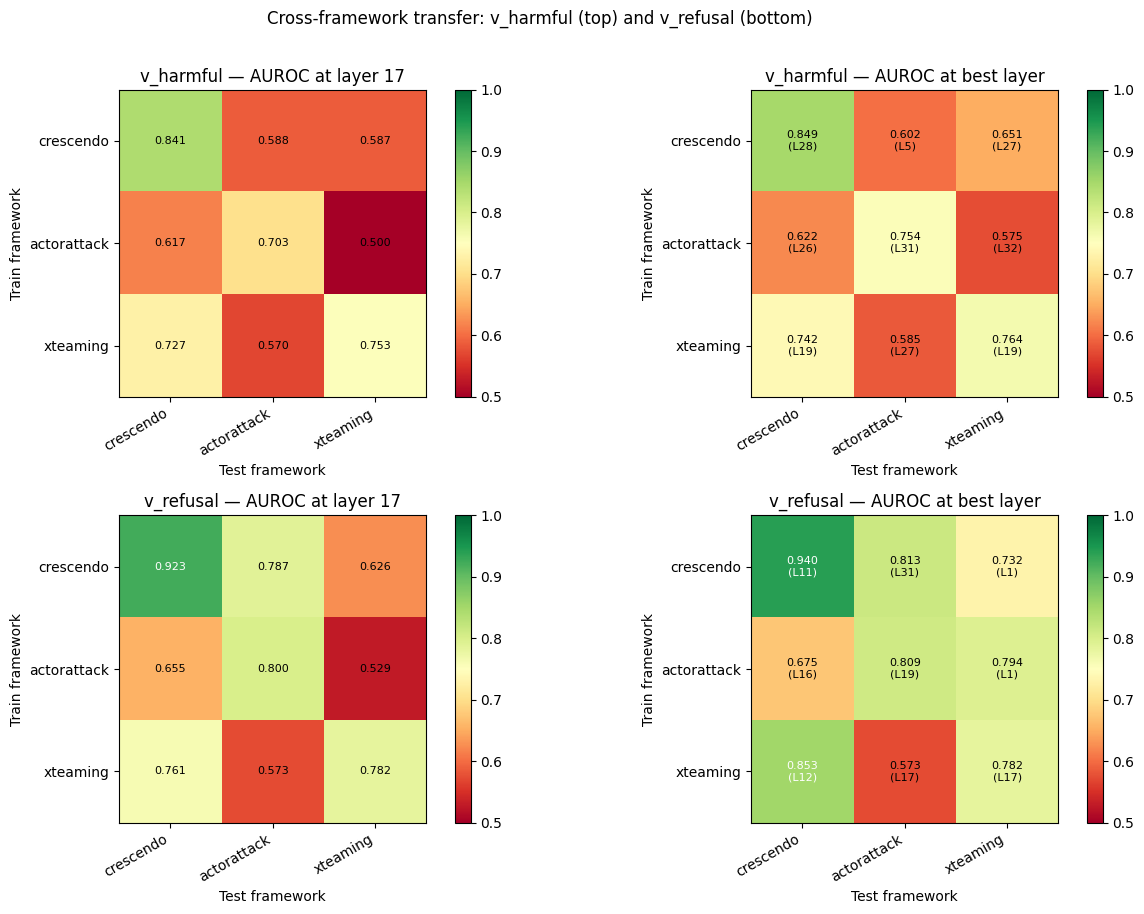

Saved figures/04_cross_framework_transfer.png

v_harmful focal-layer transfer:
             crescendo  actorattack  xteaming
crescendo        0.841        0.588     0.587
actorattack      0.617        0.703     0.500
xteaming         0.727        0.570     0.753

v_refusal focal-layer transfer:
             crescendo  actorattack  xteaming
crescendo        0.923        0.787     0.626
actorattack      0.655        0.800     0.529
xteaming         0.761        0.573     0.782


In [17]:
# ── Cross-framework transfer — all options ───────────────────────────────────
#
# One 2×2 figure per option (v_harmful top / v_refusal bottom, focal/best left/right).
# Both direction and test extraction use the same option.

def build_transfer_matrix(direction_dict, h_pos_fn, h_neg_fn):
    focal = np.zeros((3, 3))
    best  = np.zeros((3, 3))
    best_l = np.zeros((3, 3), dtype=int)
    for i, train_fw in enumerate(FRAMEWORKS):
        for j, test_fw in enumerate(FRAMEWORKS):
            h_pos, _ = h_pos_fn(test_fw)
            h_neg, _ = h_neg_fn(test_fw)
            auc_l = auroc_per_layer(h_pos, h_neg, direction_dict[train_fw])
            focal[i, j] = auc_l[FOCAL_LAYER]
            bl = int(np.nanargmax(auc_l))
            best[i, j]   = auc_l[bl]
            best_l[i, j] = bl + 1
    return focal, best, best_l


for opt_name, opt_fn in OPTION_FNS.items():
    def _hp(fw): return opt_fn(traj[(fw,'harmful')]['h_inst'], traj[(fw,'harmful')]['meta'], data_split='test')
    def _bn(fw): return opt_fn(traj[(fw,'benign' )]['h_inst'], traj[(fw,'benign' )]['meta'], data_split='test')
    def _rp(fw): return opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='refused_harmful')
    def _rn(fw): return opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='accepted_harmful')

    vh_dict = {fw: v_harmful_opts[fw][opt_name] for fw in FRAMEWORKS}
    vr_dict = {fw: v_refusal_opts[fw][opt_name] for fw in FRAMEWORKS}

    focal_h, best_h, bl_h = build_transfer_matrix(vh_dict, _hp, _bn)
    focal_r, best_r, bl_r = build_transfer_matrix(vr_dict, _rp, _rn)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    configs = [
        (axes[0,0], focal_h, None,  f'v_harmful — focal layer {FOCAL_LAYER+1}'),
        (axes[0,1], best_h,  bl_h,  'v_harmful — best layer'),
        (axes[1,0], focal_r, None,  f'v_refusal — focal layer {FOCAL_LAYER+1}'),
        (axes[1,1], best_r,  bl_r,  'v_refusal — best layer'),
    ]
    for ax, mat, bl_mat, title in configs:
        im = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap='RdYlGn')
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(FRAMEWORKS, rotation=30, ha='right')
        ax.set_yticklabels(FRAMEWORKS)
        ax.set_xlabel('Test framework'); ax.set_ylabel('Train framework')
        ax.set_title(title)
        for ii in range(3):
            for jj in range(3):
                val = mat[ii,jj]
                lbl = f'{val:.3f}' + (f'\n(L{bl_mat[ii,jj]})' if bl_mat is not None else '')
                ax.text(jj, ii, lbl, ha='center', va='center', fontsize=8,
                        color='black' if val < 0.85 else 'white')
        plt.colorbar(im, ax=ax)

    slug = opt_name.replace('-','').lower()
    plt.suptitle(f'Cross-framework transfer — Option {opt_name}', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/04_cross_fw_opt{slug}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved 04_cross_fw_opt{slug}.png')


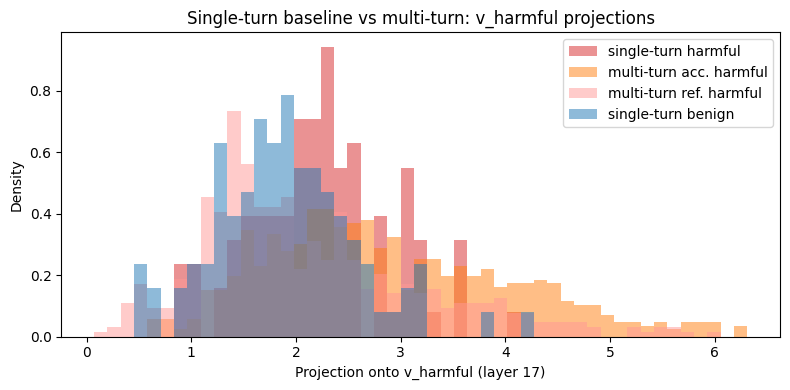

Saved figures/04_single_vs_multi_turn.png


In [18]:
# ── Single-turn baseline comparison ─────────────────────────────────────────
#
# Compare v_harmful projection distributions between:
#   - Single-turn harmful (no attack context) — baseline
#   - Multi-turn accepted_harmful (at final turn)
#   - Multi-turn refused_harmful  (at final turn)
#
# Pooled across all 3 frameworks; uses crescendo v_harmful direction.

v_dir_focal = v_harmful["crescendo"][FOCAL_LAYER]

# Single-turn projections
proj_st_harm = h_st_h[:, FOCAL_LAYER, :].astype(np.float32) @ v_dir_focal
proj_st_beni = h_st_b[:, FOCAL_LAYER, :].astype(np.float32) @ v_dir_focal

# Multi-turn (test set, all frameworks pooled)
proj_mt_acc, proj_mt_ref = [], []
for fw in FRAMEWORKS:
    h_a, _ = option_a(
        traj[(fw, "harmful")]["h_inst"], traj[(fw, "harmful")]["meta"],
        data_split="test", category="accepted_harmful",
    )
    h_r, _ = option_a(
        traj[(fw, "harmful")]["h_inst"], traj[(fw, "harmful")]["meta"],
        data_split="test", category="refused_harmful",
    )
    proj_mt_acc.append(h_a[:, FOCAL_LAYER, :].astype(np.float32) @ v_dir_focal)
    proj_mt_ref.append(h_r[:, FOCAL_LAYER, :].astype(np.float32) @ v_dir_focal)

proj_mt_acc = np.concatenate(proj_mt_acc)
proj_mt_ref = np.concatenate(proj_mt_ref)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(
    min(proj_st_harm.min(), proj_mt_acc.min(), proj_mt_ref.min(), proj_st_beni.min()),
    max(proj_st_harm.max(), proj_mt_acc.max(), proj_mt_ref.max(), proj_st_beni.max()),
    50,
)
for data, label, color, ls in [
    (proj_st_harm, "single-turn harmful",     "#d62728", "-"),
    (proj_mt_acc,  "multi-turn acc. harmful", "#ff7f0e", "--"),
    (proj_mt_ref,  "multi-turn ref. harmful", "#ff9896", ":"),
    (proj_st_beni, "single-turn benign",       "#1f77b4", "-."),
]:
    ax.hist(data, bins=bins, alpha=0.5, label=label, color=color,
            density=True, histtype="stepfilled", ls=ls)

ax.set_xlabel(f"Projection onto v_harmful (layer {FOCAL_LAYER+1})")
ax.set_ylabel("Density")
ax.set_title("Single-turn baseline vs multi-turn: v_harmful projections")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/04_single_vs_multi_turn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/04_single_vs_multi_turn.png")

In [19]:
# ── Summary table — all options ──────────────────────────────────────────────

rows = []
for opt_name, opt_fn in OPTION_FNS.items():
    for fw in FRAMEWORKS:
        h_harm_te, _ = opt_fn(traj[(fw,'harmful')]['h_inst'], traj[(fw,'harmful')]['meta'], data_split='test')
        h_beni_te, _ = opt_fn(traj[(fw,'benign' )]['h_inst'], traj[(fw,'benign' )]['meta'], data_split='test')
        hp_ref_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='refused_harmful')
        hp_acc_te, _ = opt_fn(traj[(fw,'harmful')]['h_post'], traj[(fw,'harmful')]['meta'],
                               data_split='test', category='accepted_harmful')

        auc_vh  = auroc_per_layer(h_harm_te, h_beni_te, v_harmful_opts[fw][opt_name])
        auc_xfr = auroc_per_layer(h_harm_te, h_beni_te, v_harmful_opts['crescendo'][opt_name])
        auc_vr  = auroc_per_layer(hp_ref_te, hp_acc_te, v_refusal_opts[fw][opt_name])

        mean_cv, std_cv, test_auc = probe_results[fw]  # MLP probe only for option A

        rows.append({
            'option':               opt_name,
            'framework':            fw,
            'v_harmful_peak_auc':   float(np.nanmax(auc_vh)),
            'v_harmful_peak_layer': int(np.nanargmax(auc_vh)) + 1,
            'v_harmful_xfer_auc':   float(np.nanmax(auc_xfr)),
            'v_refusal_peak_auc':   float(np.nanmax(auc_vr)),
            'v_refusal_peak_layer': int(np.nanargmax(auc_vr)) + 1,
            'mlp_test_peak_auc':    float(np.nanmax(test_auc)),   # option A only
            'mlp_peak_layer':       int(np.nanargmax(test_auc)) + 1,
        })

df_summary = pd.DataFrame(rows).set_index(['option','framework']).round(3)
display(df_summary)


,n_test_harmful,n_test_benign,v_harmful_peak_auc,v_harmful_peak_layer,v_harmful_xfer_auc,v_refusal_peak_auc,v_refusal_peak_layer,mlp_cv_peak_auc,mlp_test_peak_auc,mlp_peak_layer
framework,,,,,,,,,,
crescendo,397,397,0.849,28,0.849,0.940,11,0.891,0.966,21
actorattack,399,400,0.754,31,0.602,0.809,19,0.762,0.940,27
xteaming,388,400,0.764,19,0.651,0.782,17,0.824,0.887,20
